In [ ]:
# ===============================================================
# STOCHASTIC MODELLING OF STOCK PRICES PROJECT
# Using Brownian Motion, Geometric Brownian Motion (GBM) & Linear Regression
# Guide: Dr. Akash Ashirbad Panda
# Project by: Vigneshwaran P
# ===============================================================

# ===============================================================
# STEP 1: INSTALL AND IMPORT NECESSARY LIBRARIES
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set styling for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Set random seed for reproducibility
np.random.seed(42)

print("="*70)
print("STOCHASTIC MODELLING OF STOCK PRICES")
print("Using Brownian Motion, GBM & Linear Regression")
print("IIT Bhubaneswar - MSc Mathematics Project")
print("="*70)
print("\n✓ All libraries imported successfully!\n")

STOCHASTIC MODELLING OF STOCK PRICES
Using Brownian Motion, GBM & Linear Regression
IIT Bhubaneswar - MSc Mathematics Project

✓ All libraries imported successfully!



In [ ]:
# ===============================================================
# STEP 2: LOAD AND EXPLORE THE DATASET
# ===============================================================
print("="*70)
print("STEP 2: DATA LOADING AND EXPLORATION")
print("="*70)

from google.colab import files
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]

# Load the dataset
data = pd.read_csv(filename)

# Display basic information
print(f"\n✓ Dataset loaded: {filename}")
print(f"Data shape: {data.shape}")
print(f"\nFirst 10 rows:")
print(data.head(10))

print(f"\nData information:")
print(data.info())

print(f"\nColumn names:")
print(data.columns.tolist())

print(f"\nMissing values:")
print(data.isnull().sum())


STEP 2: DATA LOADING AND EXPLORATION


Saving NESTLEIND.csv to NESTLEIND.csv

✓ Dataset loaded: NESTLEIND.csv
Data shape: (2806, 15)

First 10 rows:
         Date     Symbol Series  Prev Close     Open    High      Low  \
0  2010-01-08  NESTLEIND     EQ     2512.95  2555.00  2575.0  2475.20   
1  2010-01-11  NESTLEIND     EQ     2494.65  2401.00  2515.0  2400.00   
2  2010-01-12  NESTLEIND     EQ     2498.95  2540.00  2540.0  2471.35   
3  2010-01-13  NESTLEIND     EQ     2502.85  2502.85  2540.0  2480.00   
4  2010-01-14  NESTLEIND     EQ     2489.35  2535.00  2595.0  2470.00   
5  2010-01-15  NESTLEIND     EQ     2568.20  2580.00  2580.0  2500.05   
6  2010-01-18  NESTLEIND     EQ     2513.50  2574.00  2574.0  2514.00   
7  2010-01-19  NESTLEIND     EQ     2536.15  2567.00  2570.0  2531.00   
8  2010-01-20  NESTLEIND     EQ     2556.10  2550.00  2575.0  2540.00   
9  2010-01-21  NESTLEIND     EQ     2542.50  2539.90  2569.0  2499.90   

      Last    Close     VWAP  Volume      Turnover  Trades  \
0  2476.00  2494.65  252

In [ ]:
# ===============================================================
# STEP 3: DATA PREPROCESSING
# ===============================================================
print("\n" + "="*70)
print("STEP 3: DATA PREPROCESSING")
print("="*70)

# Define column names
date_column = 'Date'
price_column = 'Close'

# Convert Date column to datetime and sort
data[date_column] = pd.to_datetime(data[date_column])
data = data.sort_values(date_column).reset_index(drop=True)

print("✓ Date column converted to datetime format")

# Handle missing values in Close price
if data[price_column].isnull().sum() > 0:
    data[price_column].fillna(method='ffill', inplace=True)
    print("✓ Missing values handled using forward fill")

# Check for duplicates
duplicates = data.duplicated().sum()
print(f"Number of duplicates: {duplicates}")
if duplicates > 0:
    data = data.drop_duplicates()
    print("✓ Duplicates removed")

# Calculate returns and additional features
data['Log_Returns'] = np.log(data[price_column] / data[price_column].shift(1))
data['Log_Returns'].fillna(0, inplace=True)

data['Simple_Returns'] = data[price_column].pct_change()
data['Simple_Returns'].fillna(0, inplace=True)

data['Daily_Change_Pct'] = data['Simple_Returns'] * 100

print("✓ Daily returns calculated (both log and simple)")

# Descriptive Statistics
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)
print(data[[price_column, 'Log_Returns', 'Simple_Returns']].describe())


STEP 3: DATA PREPROCESSING
✓ Date column converted to datetime format
Number of duplicates: 0
✓ Daily returns calculated (both log and simple)

DESCRIPTIVE STATISTICS
              Close  Log_Returns  Simple_Returns
count   2806.000000  2806.000000     2806.000000
mean    7512.039647     0.000669        0.000785
std     4182.705331     0.015208        0.015258
min     2489.350000    -0.094958       -0.090589
25%     4644.025000    -0.007725       -0.007695
50%     6122.550000     0.000217        0.000217
75%     9683.412500     0.008576        0.008613
max    18732.700000     0.120482        0.128040



STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
✓ Comprehensive EDA visualizations created and saved


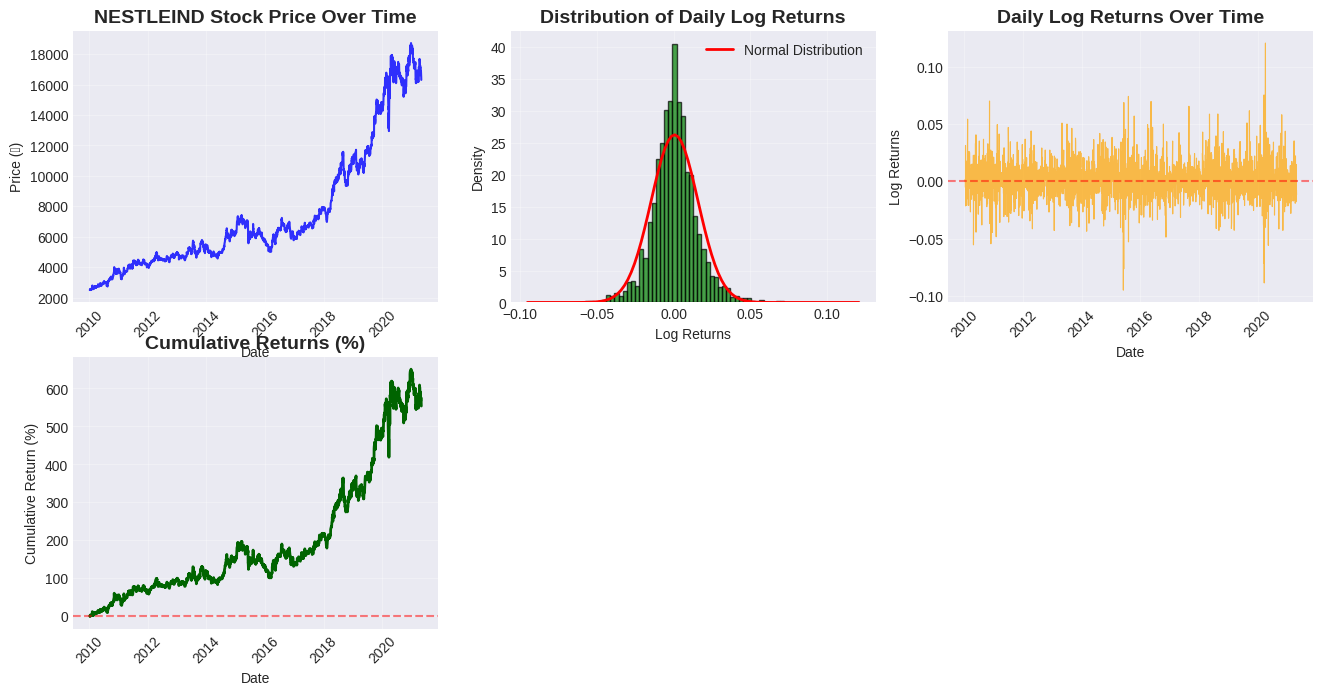

In [ ]:
# ===============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ===============================================================
print("\n" + "="*70)
print("STEP 4: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

# Create comprehensive EDA visualizations
fig = plt.figure(figsize=(16,12))

# Plot 1: Stock Price Over Time
plt.subplot(3, 3, 1)
plt.plot(data[date_column], data[price_column], linewidth=1.5, color='blue', alpha=0.8)
plt.title('NESTLEIND Stock Price Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Daily Log Returns Distribution
plt.subplot(3, 3, 2)
plt.hist(data['Log_Returns'].dropna(), bins=80, density=True, alpha=0.7,
         color='green', edgecolor='black')
plt.title('Distribution of Daily Log Returns', fontsize=14, fontweight='bold')
plt.xlabel('Log Returns')
plt.ylabel('Density')
# Add normal distribution for comparison
x = np.linspace(data['Log_Returns'].min(), data['Log_Returns'].max(), 100)
plt.plot(x, stats.norm.pdf(x, data['Log_Returns'].mean(), data['Log_Returns'].std()),
         'r-', linewidth=2, label='Normal Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Returns Over Time
plt.subplot(3, 3, 3)
plt.plot(data[date_column], data['Log_Returns'], linewidth=0.8, alpha=0.7, color='orange')
plt.title('Daily Log Returns Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Plot 4: Cumulative Returns
plt.subplot(3, 3, 4)
cumulative_returns = (1 + data['Simple_Returns']).cumprod() - 1
plt.plot(data[date_column], cumulative_returns * 100, linewidth=2, color='darkgreen')
plt.title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)



print("✓ Comprehensive EDA visualizations created and saved")

In [ ]:
# ===============================================================
# STEP 5: MATHEMATICAL THEORY - PARAMETER ESTIMATION (MLE)
# ===============================================================
print("\n" + "="*70)
print("STEP 5: PARAMETER ESTIMATION USING MAXIMUM LIKELIHOOD")
print("="*70)

class GBMParameterEstimator:
    """
    Maximum Likelihood Estimation for Geometric Brownian Motion parameters

    Mathematical Theory:
    GBM: dS = μS dt + σS dW
    Where: S = stock price, μ = drift, σ = volatility, W = Wiener process

    For discrete returns: ln(S_t/S_{t-1}) ~ N((μ - σ²/2)Δt, σ²Δt)
    """

    def __init__(self):
        self.mu_estimated = None
        self.sigma_estimated = None
        self.log_likelihood = None

    def estimate_parameters(self, prices):
        """Estimate drift (μ) and volatility (σ) using Maximum Likelihood Estimation"""
        log_returns = np.diff(np.log(prices))
        n = len(log_returns)
        dt = 1/252  # Assuming 252 trading days in a year

        # MLE estimates
        sample_mean = np.mean(log_returns)
        sample_var = np.var(log_returns, ddof=1)

        # Estimate parameters
        self.sigma_estimated = np.sqrt(sample_var / dt)
        self.mu_estimated = sample_mean / dt + 0.5 * self.sigma_estimated**2

        return self.mu_estimated, self.sigma_estimated

# Estimate parameters
estimator = GBMParameterEstimator()
prices = data[price_column].values
mu_est, sigma_est = estimator.estimate_parameters(prices)

# Calculate actual historical statistics
annual_return_actual = data['Log_Returns'].mean() * 252
annual_volatility_actual = data['Log_Returns'].std() * np.sqrt(252)

print("\n GEOMETRIC BROWNIAN MOTION PARAMETERS")
print("="*50)
print("Mathematical Formulation:")
print("dS = μS dt + σS dW")
print("where:")
print("S = Stock Price, μ = Drift, σ = Volatility, W = Wiener Process")
print("="*50)
print(f"Estimated Drift (μ): {mu_est:.4f}")
print(f"Estimated Volatility (σ): {sigma_est:.4f}")
print("="*50)
print(f"Annualized Expected Return (Estimated): {mu_est:.2%}")
print(f"Annualized Volatility (Estimated): {sigma_est:.2%}")
print("="*50)
print(f"Actual Historical Annual Return: {annual_return_actual:.2%}")
print(f"Actual Historical Annual Volatility: {annual_volatility_actual:.2%}")
print("="*50)


STEP 5: PARAMETER ESTIMATION USING MAXIMUM LIKELIHOOD

 GEOMETRIC BROWNIAN MOTION PARAMETERS
Mathematical Formulation:
dS = μS dt + σS dW
where:
S = Stock Price, μ = Drift, σ = Volatility, W = Wiener Process
Estimated Drift (μ): 0.1978
Estimated Volatility (σ): 0.2415
Annualized Expected Return (Estimated): 19.78%
Annualized Volatility (Estimated): 24.15%
Actual Historical Annual Return: 16.86%
Actual Historical Annual Volatility: 24.14%


In [ ]:
# ===============================================================
# STEP 6: MONTE CARLO SIMULATION USING GBM
# ===============================================================
print("\n" + "="*70)
print("STEP 6: MONTE CARLO SIMULATION WITH GBM")
print("="*70)

class MonteCarloGBMSimulator:
    """
    Monte Carlo Simulation for Geometric Brownian Motion

    Mathematical Formulation:
    S_t = S_0 * exp((μ - σ²/2)t + σW_t)
    Where W_t ~ N(0, t) is a Wiener process
    """

    def __init__(self, mu, sigma, S0):
        self.mu = mu
        self.sigma = sigma
        self.S0 = S0

    def simulate_paths(self, T, dt, num_simulations=1000):
        """Simulate multiple GBM paths using Monte Carlo method"""
        N = int(T / dt)  # Number of time steps
        t = np.linspace(0, T, N)

        paths = np.zeros((num_simulations, N))
        paths[:, 0] = self.S0

        # Vectorized simulation for better performance
        for i in range(num_simulations):
            # Generate Brownian motion increments
            dW = np.random.normal(0, np.sqrt(dt), N-1)
            # Cumulative Brownian motion
            W = np.cumsum(dW)
            W = np.insert(W, 0, 0)  # Start at 0

            # GBM formula: S_t = S_0 * exp((μ - σ²/2)t + σW_t)
            paths[i, :] = self.S0 * np.exp((self.mu - 0.5 * self.sigma**2) * t + self.sigma * W)

        return paths, t

# Create simulator instance
current_price = data[price_column].iloc[-1]
simulator = MonteCarloGBMSimulator(mu=mu_est, sigma=sigma_est, S0=current_price)

# Simulation parameters
forecast_horizon = 1.0  # 1 year
dt = 1/252  # Daily time steps
num_simulations = 5000

print(f"\n Running {num_simulations} Monte Carlo Simulations...")
print(f"Forecast Horizon: {forecast_horizon} year(s)")
print(f"Current Price: ₹{current_price:.2f}")
print(f"Time Step (dt): {dt:.4f} years")

# Run simulation
mc_paths, mc_time = simulator.simulate_paths(forecast_horizon, dt, num_simulations)
final_prices = mc_paths[:, -1]

# Calculate simulation statistics
print("\n MONTE CARLO FORECAST RESULTS")
print("="*50)
print(f"Mean Forecasted Price: ₹{np.mean(final_prices):.2f}")
print(f"Median Forecasted Price: ₹{np.median(final_prices):.2f}")
print(f"Standard Deviation: ₹{np.std(final_prices):.2f}")
print("="*50)



STEP 6: MONTE CARLO SIMULATION WITH GBM

 Running 5000 Monte Carlo Simulations...
Forecast Horizon: 1.0 year(s)
Current Price: ₹16309.25
Time Step (dt): 0.0040 years

 MONTE CARLO FORECAST RESULTS
Mean Forecasted Price: ₹19760.54
Median Forecasted Price: ₹19126.33
Standard Deviation: ₹4834.09



STEP 7: MONTE CARLO VISUALIZATION
✓ Monte Carlo visualizations created and saved


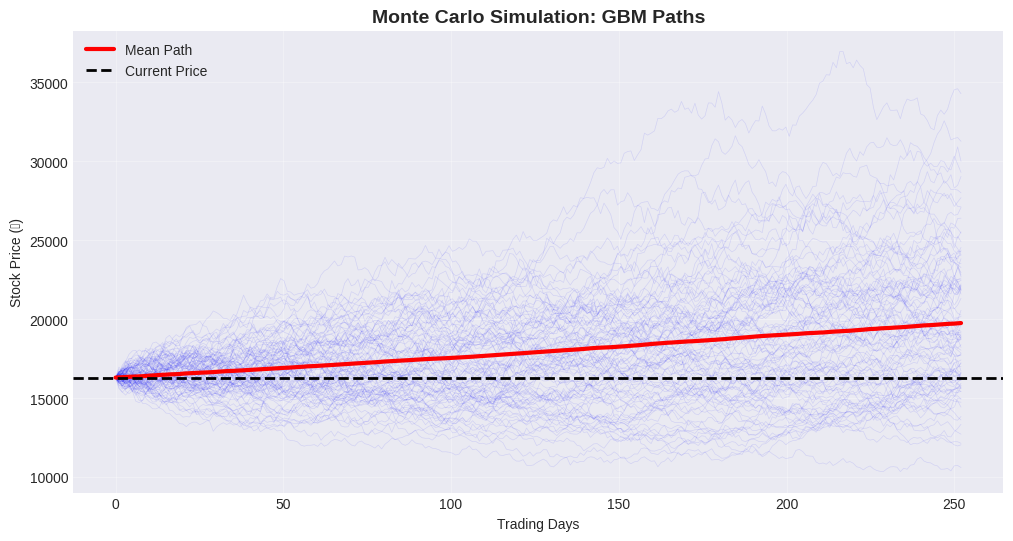

In [ ]:
# ===============================================================
# STEP 7: VISUALIZATION OF MONTE CARLO RESULTS
# ===============================================================
print("\n" + "="*70)
print("STEP 7: MONTE CARLO VISUALIZATION")
print("="*70)

fig = plt.figure(figsize=(12, 6))

# Plot 1: Monte Carlo Simulation Paths
plt.subplot(1, 1, 1)
# Plot a subset of paths for clarity
sample_paths = mc_paths[:100]  # First 100 paths
for i, path in enumerate(sample_paths):
    plt.plot(mc_time * 252, path, alpha=0.1, linewidth=0.5, color='blue')
plt.plot(mc_time * 252, np.mean(mc_paths, axis=0), 'r-', linewidth=3, label='Mean Path')
plt.axhline(current_price, color='black', linestyle='--', linewidth=2, label='Current Price')
plt.title('Monte Carlo Simulation: GBM Paths', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)

print("✓ Monte Carlo visualizations created and saved")


STEP 8: MACHINE- LINEAR REGRESSION MODEL
Features used for Linear Regression: ['Close', 'MA_5', 'MA_20', 'MA_50', 'Volatility', 'Momentum']
Dataset shape for ML: (2455, 6)
Training set size: 1964
Testing set size: 491

 LINEAR REGRESSION PERFORMANCE
R² Score: 0.9834
Mean Absolute Error (MAE): ₹188.89
Root Mean Squared Error (RMSE): ₹271.61
Mean Absolute Percentage Error (MAPE): 1.22%

 FEATURE IMPORTANCE (Linear Regression)
Volatility   :  -623.6299
Momentum     :   -75.5564
Close        :     0.9971
MA_50        :     0.0159
MA_20        :    -0.0143
MA_5         :     0.0016


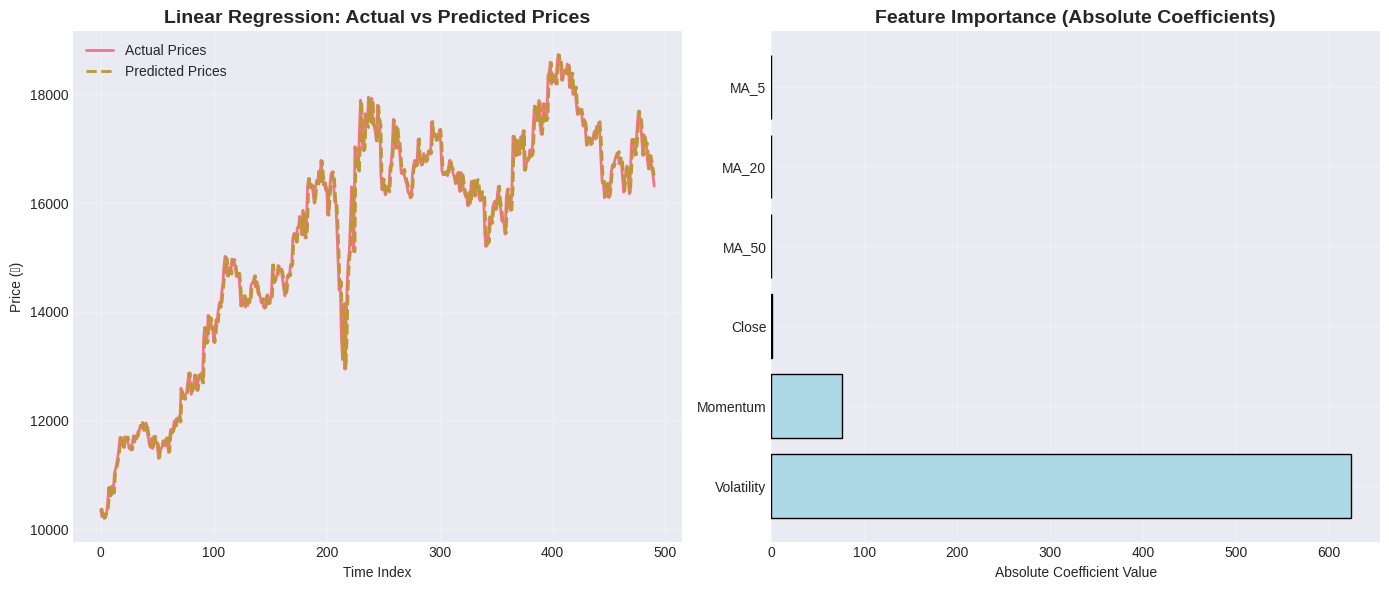

✓ Linear Regression analysis completed and visualizations saved


In [ ]:
# ===============================================================
# STEP 8: MACHINE LEARNING - LINEAR REGRESSION
# ===============================================================
print("\n" + "="*70)
print("STEP 8: MACHINE- LINEAR REGRESSION MODEL")
print("="*70)

# Create features for linear regression
ml_data = data.copy()

# Technical indicators as features
ml_data['MA_5'] = ml_data[price_column].rolling(window=5).mean()
ml_data['MA_20'] = ml_data[price_column].rolling(window=20).mean()
ml_data['MA_50'] = ml_data[price_column].rolling(window=50).mean()
ml_data['Volatility'] = ml_data['Log_Returns'].rolling(window=20).std()
ml_data['Momentum'] = ml_data[price_column] / ml_data[price_column].shift(5) - 1

# Target variable: Next day's closing price
ml_data['Next_Close'] = ml_data[price_column].shift(-1)

# Drop NaN values
ml_data = ml_data.dropna()

# Feature selection
features = ['Close', 'MA_5', 'MA_20', 'MA_50', 'Volatility', 'Momentum']
X = ml_data[features]
y = ml_data['Next_Close']

print(f"Features used for Linear Regression: {features}")
print(f"Dataset shape for ML: {X.shape}")

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Calculate performance metrics
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)
mape_lr = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n LINEAR REGRESSION PERFORMANCE")
print("="*50)
print(f"R² Score: {r2_lr:.4f}")
print(f"Mean Absolute Error (MAE): ₹{mae_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse_lr:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_lr:.2f}%")
print("="*50)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_,
    'Absolute_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Absolute_Coefficient', ascending=False)

print("\n FEATURE IMPORTANCE (Linear Regression)")
print("="*40)
for _, row in feature_importance.iterrows():
    print(f"{row['Feature']:12} : {row['Coefficient']:10.4f}")

# Visualization of Linear Regression results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs Predicted
axes[0].plot(y_test.values, label='Actual Prices', linewidth=2)
axes[0].plot(y_pred, '--', label='Predicted Prices', linewidth=2)
axes[0].set_title('Linear Regression: Actual vs Predicted Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Index')
axes[0].set_ylabel('Price (₹)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature Importance
axes[1].barh(feature_importance['Feature'], feature_importance['Absolute_Coefficient'],
             color='lightblue', edgecolor='black')
axes[1].set_title('Feature Importance (Absolute Coefficients)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Absolute Coefficient Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Linear Regression analysis completed and visualizations saved")


In [ ]:
# ===============================================================
# STEP 9: RISK METRICS CALCULATION
# ===============================================================
print("\n" + "="*70)
print("STEP 9: COMPREHENSIVE RISK METRICS")
print("="*70)

# Calculate comprehensive risk metrics
returns = data['Log_Returns'].dropna().values

# Value at Risk (VaR)
var_5 = np.percentile(returns, 5)
var_1 = np.percentile(returns, 1)

# Conditional Value at Risk (CVaR) / Expected Shortfall
cvar_5 = returns[returns <= var_5].mean()
cvar_1 = returns[returns <= var_1].mean()


print("\n COMPREHENSIVE RISK METRICS")
print("="*60)
print("Value at Risk (VaR):")
print(f"  Daily VaR (95% confidence):   {var_5:.4f} ({var_5*100:.2f}%)")
print(f"  Daily VaR (99% confidence):   {var_1:.4f} ({var_1*100:.2f}%)")
print(f"  Annual VaR (95% confidence):  {var_5 * np.sqrt(252):.4f} ({var_5 * np.sqrt(252)*100:.2f}%)")
print("\nConditional VaR (CVaR/Expected Shortfall):")
print(f"  Daily CVaR (95% confidence):  {cvar_5:.4f} ({cvar_5*100:.2f}%)")
print(f"  Daily CVaR (99% confidence):  {cvar_1:.4f} ({cvar_1*100:.2f}%)")
print("="*60)


STEP 9: COMPREHENSIVE RISK METRICS

 COMPREHENSIVE RISK METRICS
Value at Risk (VaR):
  Daily VaR (95% confidence):   -0.0217 (-2.17%)
  Daily VaR (99% confidence):   -0.0391 (-3.91%)
  Annual VaR (95% confidence):  -0.3448 (-34.48%)

Conditional VaR (CVaR/Expected Shortfall):
  Daily CVaR (95% confidence):  -0.0326 (-3.26%)
  Daily CVaR (99% confidence):  -0.0497 (-4.97%)


In [ ]:

# ===============================================================
# FINAL SUMMARY
# ===============================================================
print("\n" + "="*70)
print("PROJECT COMPLETED  ")
print("="*70)

print(f"\n KEY RESULTS:")
print(f"   * Estimated Annual Return (μ): {mu_est:.2%}")
print(f"   * Estimated Volatility (σ): {sigma_est:.2%}")
print(f"   * 1-Year Mean Forecast: ₹{np.mean(final_prices):.2f}")
print(f"   * Probability of Profit: {np.mean(final_prices > current_price):.1%}")
print(f"   * Linear Regression R²: {r2_lr:.4f}")


PROJECT COMPLETED  

 KEY RESULTS:
   * Estimated Annual Return (μ): 19.78%
   * Estimated Volatility (σ): 24.15%
   * 1-Year Mean Forecast: ₹19760.54
   * Probability of Profit: 74.8%
   * Linear Regression R²: 0.9834
